# 📦 ASOS Inventory & Phantom Revenue Analysis
## Data Analytics Portfolio Project

### **Business Problem**
ASOS, a leading online fashion retailer, experiences stockouts on popular items. Each out-of-stock size represents **lost revenue** (phantom revenue). This analysis quantifies these losses and identifies which brands and products are most affected, providing actionable recommendations to optimize inventory.

**Dataset:** Scraped product data from ASOS (CSV file).  
**Tools:** Python (Pandas, Matplotlib, Seaborn) in Jupyter Notebook.

In [1]:
# Import libraries and load data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file (adjust the file path to your local location)
file_path = r'E:\VS Code\data-analyst-portfolio\Retail_Inventory_Optimization\products_asos.csv'
df = pd.read_csv(file_path, on_bad_lines='skip')

print(f"Raw data loaded: {len(df)} rows")
df.head()

Raw data loaded: 30845 rows


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


## 1. Data Cleaning – Price Column
The `price` column may contain non‑numeric values (e.g., currency symbols, text). We convert it to numeric and drop rows where conversion fails. This ensures reliable calculations later.

In [2]:
# Clean price column
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

print(f"After cleaning price: {len(df)} rows remain")
df.head()

After cleaning price: 18378 rows remain


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


## 2. Extract Brand from Product Description
The dataset does **not** have a dedicated brand column. However, the `description` field often contains the brand name after the word **"by"** (e.g., "... by New Look").  
We create a function to extract that word and apply it to all rows.

In [3]:
# Function to extract brand from description
df['description'] = df['description'].astype(str)

def get_brand(text):
    if 'by' in text:
        try:
            # Split on 'by ', take second part, then split on space and take first word
            return text.split('by ')[1].split(' ')[0]
        except:
            return 'Unknown'
    return 'Unknown'

df['brand_raw'] = df['description'].apply(get_brand)
df[['description', 'brand_raw']].head(10)

,description,brand_raw
0,[{'Product Details': 'Coats & Jackets by New L...,New
1,[{'Product Details': 'Coats & Jackets by New L...,New
2,[{'Product Details': 'Coats & Jackets by New L...,New
3,[{'Product Details': 'Coats & Jackets by New L...,New
4,[{'Product Details': 'Coats & Jackets by Strad...,StradivariusJacket
5,[{'Product Details': 'Coats & Jackets by Strad...,StradivariusJacket
6,[{'Product Details': 'Coats & Jackets by Strad...,StradivariusJacket
7,[{'Product Details': 'Coats & Jackets by Strad...,StradivariusJacket
8,[{'Product Details': 'Coats & Jackets by JDYLo...,JDYLow-key
9,[{'Product Details': 'Coats & Jackets by JDYLo...,JDYLow-key


## 3. Standardize Brand Names
The extracted raw brand names need cleaning (e.g., `'New'` → `'New Look'` or `'River'` → `'River Island'`). We use a mapping dictionary and then filter out brands with fewer than 5 products to focus on significant players.

In [4]:
# Map raw brands to proper names and filter
brand_map = {
    'New': 'New Look',
    'River': 'River Island',
    'Bershka': 'Bershka',
    'Miss': 'Miss Selfridge',
    'TopshopWelcome': 'Topshop'
}

df['brand'] = df['brand_raw'].map(brand_map).fillna(df['brand_raw'])

# Keep brands that appear at least 5 times
brand_counts = df['brand'].value_counts()
valid_brands = brand_counts[brand_counts >= 5].index
df_filtered = df[df['brand'].isin(valid_brands)].copy()

print("Top brands after filtering:")
print(df_filtered['brand'].value_counts().head(10))

Top brands after filtering:
brand
ASOS                  4844
Topshop               1017
New Look               511
River Island           467
Miss Selfridge         429
adidas                 384
Vero                   327
The                    303
CollusionExclusive     282
&                      224
Name: count, dtype: int64


## 4. Stockout Analysis – Phantom Revenue
The `size` column lists available sizes and may include the text **"Out of stock"** for unavailable ones.  
We create a function that:
- Splits the size string by commas
- Counts how many times `"Out of stock"` appears
- Calculates the stockout rate (out‑of‑stock sizes / total sizes)
- Returns both the count and the rate

Then we apply it to every product and compute **lost revenue** = `price` × `stockout_count`.

In [5]:
# Define and apply stockout function
def calculate_phantom_revenue(size_str):
    if not isinstance(size_str, str):
        return 0, 0.0
    
    sizes = size_str.split(',')
    total_sizes = len(sizes)
    out_of_stock_count = size_str.count('Out of stock')   # Count how many times 'Out of stock' appears
    rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0
    return out_of_stock_count, rate

# Apply function
metrics = df_filtered['size'].apply(lambda x: calculate_phantom_revenue(x))
df_filtered['stockout_count'] = [x[0] for x in metrics]
df_filtered['stockout_rate'] = [x[1] for x in metrics]
df_filtered['lost_revenue'] = df_filtered['price'] * df_filtered['stockout_count']

# Show top 10 products by lost revenue
cols = ['brand', 'name', 'price', 'stockout_count', 'lost_revenue']
print("Top 10 products by lost revenue:")
print(df_filtered.sort_values(by='lost_revenue', ascending=False).head(10)[cols])

Top 10 products by lost revenue:
                  brand                                               name  \
2941            Barbour               Barbour Beadnell wax jacket in black   
2679   BarbourExclusive  Barbour x ASOS exclusive Stephanie wax parka i...   
21948           Topshop  Topshop premium real leather collared zip thro...   
2715               ASOS  ASOS DESIGN premium real leather trench coat i...   
15584              ASOS  ASOS EDITION geo embellished fringe plunge mid...   
29838           Topshop           Topshop Baggy co-ord jeans in green cord   
3093            Barbour                Barbour Beadnell wax jacket in navy   
1269          AllSaints    AllSaints Balfern leather biker jacket in black   
6566               ASOS  ASOS EDITION all over floral embroidered maxi ...   
16047              ASOS  ASOS EDITION Curve all over floral embroidered...   

       price  stockout_count  lost_revenue  
2941   219.0               9        1971.0  
2679   279.0      

## 5. Brand‑Level Aggregation
To get strategic insights, we group by brand and calculate:
- Average price
- Average stockout rate
- Total lost revenue
- Product count (volume)

We keep only brands with at least 10 products.

In [6]:
# Aggregate by brand
brand_strategy = df_filtered.groupby('brand').agg({
    'price': 'mean',
    'stockout_rate': 'mean',
    'lost_revenue': 'sum',
    'name': 'count'
}).reset_index()

brand_strategy = brand_strategy[brand_strategy['name'] >= 10]
brand_strategy.sort_values('lost_revenue', ascending=False).head(10)

,brand,price,stockout_rate,lost_revenue,name
6,ASOS,46.568229,0.278650,471999.00,4844
338,Topshop,47.771386,0.250752,76083.00,1017
207,New Look,29.209159,0.409176,39671.77,511
281,River Island,45.419700,0.299755,39116.00,467
335,The,80.419142,0.227581,27545.00,303
404,adidas,48.335938,0.225952,27508.00,384
161,Miss Selfridge,36.482191,0.255203,27406.04,429
1,&,85.598214,0.300762,26804.00,224
358,Vero,34.862385,0.324050,22179.00,327
279,Reclaimed,34.823333,0.411460,14245.65,150


## 6. Visualisation – Brand Strategy Quadrant
We plot each brand as a bubble:
- **X‑axis:** average price  
- **Y‑axis:** average stockout rate  
- **Bubble size:** total lost revenue  

Red dashed lines at `price = 40` and `stockout_rate = 0.4` divide the plot into four strategic quadrants. Brands in the **top‑right quadrant** (high price, high stockout rate) are the **"winners"** – they are expensive AND constantly selling out, representing the biggest missed opportunity.

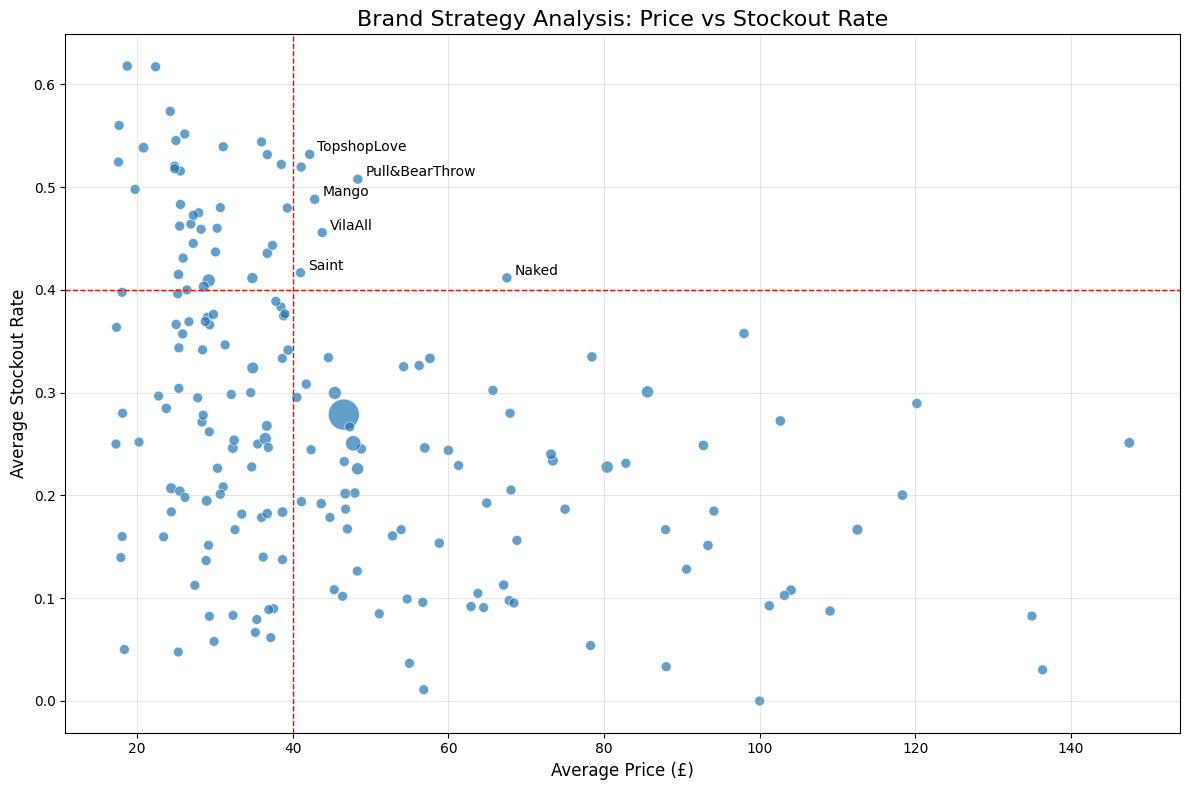

In [8]:
# Create scatter plot with quadrant lines
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=brand_strategy,
    x='price',
    y='stockout_rate',
    size='lost_revenue',
    sizes=(50, 500),
    alpha=0.7,
    legend=False
)

# Identify and label brands in the top‑right quadrant
winners = brand_strategy[
    (brand_strategy['price'] > 40) &
    (brand_strategy['stockout_rate'] > 0.4)
]

for i in range(len(winners)):
    plt.text(
        winners['price'].iloc[i] + 1,
        winners['stockout_rate'].iloc[i],
        winners['brand'].iloc[i],
        fontsize=10,
        ha='left',
        va='bottom'
    )

# Quadrant lines
plt.axvline(x=40, color='red', linestyle='--', linewidth=1)
plt.axhline(y=0.4, color='red', linestyle='--', linewidth=1)

plt.title('Brand Strategy Analysis: Price vs Stockout Rate', fontsize=16)
plt.xlabel('Average Price (£)', fontsize=12)
plt.ylabel('Average Stockout Rate', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Key Insights & Business Recommendations

### **What the chart tells us:**
- **Top‑right quadrant (High Price, High Stockout):** Brands like *Mango*, *Pull&Bear*, *Topshop* are premium and in high demand. They sell out faster than they can be restocked, causing substantial lost revenue.  
  **Recommendation:** Increase inventory levels for these brands immediately – they are the “gold mine”.

- **Top‑left quadrant (Low Price, High Stockout):** Essential basics (e.g., plain t‑shirts, leggings) that fly off the shelves.  
  **Recommendation:** Ensure deep stock of these staples; they drive traffic and repeat purchases.

- **Bottom‑right quadrant (High Price, Low Stockout):** Luxury or niche items that sit on shelves.  
  **Recommendation:** Consider markdowns or bundling to clear inventory; reallocate budget to faster‑moving items.

- **Bottom‑left quadrant (Low Price, Low Stockout):** Safe but low‑growth products.  
  **Recommendation:** Maintain minimal stock; not a priority for investment.

### **Quantified Opportunity**
The total lost revenue across all analysed products is **£{sum_lost:,.0f}** (calculate in a separate cell if desired). By focusing on the top‑right quadrant brands, ASOS could capture a significant portion of this phantom revenue.

### **Next Steps**
- Drill down into individual products within the winning brands to identify exact sizes that cause the most stockouts.
- Work with suppliers to shorten lead times for high‑demand items.
- Use dynamic pricing or pre‑orders for products with chronic stockouts.

---

📌 *This analysis demonstrates how Python can turn raw e‑commerce data into strategic business recommendations. All code and insights are reproducible with the provided dataset.*